# PFS x DESI Multi-Tracer Fisher Forecast --- Figures

This notebook reproduces all figures from the paper.

**Three analysis scenarios:**
- **Broad**: conservative Gaussian priors ([Chudaykin+ 2025](https://arxiv.org/abs/2507.13433))
- **Cross-cal**: priors calibrated from the PFS--DESI overlap ($k_{\rm max} = 0.20\,h{\rm Mpc}^{-1}$)
- **Fixed nuisance**: nuisance parameters perfectly known (theoretical ceiling)

**SBP benchmark lines:**
- **SBP, PS**: power-spectrum-level simulation-based prior ([Zhang+ 2025](https://arxiv.org/abs/2409.12937))
- **SBP, FL**: field-level simulation-based prior ([Chudaykin+ 2026](https://arxiv.org/abs/2602.18554))

**Key parameters:**
- `f_shared = 0.045`: shared ELG fraction between PFS and DESI, `f_shared=n_shared/n_PFS`
- `r_sigma_v = 0.75`: FoG velocity ratio `sigma_v,PFS / sigma_v,DESI`
- Asymmetric kmax in overlap: `kmax_PFS = kmax_DESI / r_sigma_v`

In [1]:
import os
from pathlib import Path
if Path().resolve().name == "notebooks":
    os.chdir(Path().resolve().parent)  # -> repo root
n_cpus = str(os.cpu_count())
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = n_cpus
os.environ['OPENBLAS_NUM_THREADS'] = n_cpus
os.environ['MKL_NUM_THREADS'] = n_cpus

import sys
sys.path.insert(0, ".")

import jax
jax.config.update("jax_enable_x64", True)

import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams.update({
    "text.usetex": False,
    "font.size": 24})
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6.0
plt.rcParams['ytick.major.size'] = 6.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.minor.size'] = 4.0
plt.rcParams['ytick.minor.size'] = 4.0
plt.rcParams['xtick.minor.width'] = 0.8
plt.rcParams['ytick.minor.width'] = 0.8
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['font.size'] = 24
plt.rcParams['axes.linewidth'] = 1.5
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

In [2]:
# Run the pipeline (~30s)
from pfsfog.config import ForecastConfig
from pfsfog.cli import run_pipeline

cfg = ForecastConfig.from_yaml("configs/default.yaml")
results = run_pipeline(cfg, verbose=True)

Output → results/20260426_154100

=== Step 1: Overlap calibration ===
  Asymmetric kmax: DESI=0.200, PFS=0.267, cross=0.267 h/Mpc
  k_low: 39 bins to 0.200, k_high: 13 bins to 0.265
Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.
Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that 

In [3]:
from pfsfog.plots import set_style
set_style()

# Convenient references
overlap = results.overlap_results        # {(zlo,zhi): OverlapResult}
scenarios = results.scenario_results      # {"broad": ScenarioResult, ...}
z_bins = results.config.z_bins
sorted_zbins = sorted(overlap.keys())

from pfsfog.eft_params import broad_priors, NUISANCE_NAMES, HOD_BENCHMARK, FIELD_LEVEL_BENCHMARK
from pfsfog.scenarios import SCENARIOS, compute_calibration_efficiency

COLORS = {"broad": "C0", "cross-cal": "C2", "oracle": "C1"}
LABELS = {"broad": "Broad", "cross-cal": "Calibrated", "oracle": "Fixed"}
scenario_names = [s.name for s in SCENARIOS]
cosmo_params = ["fsigma8", "Mnu", "Omegam"]

## Figure 1 --- Calibrated vs broad priors

Broad prior widths (bars) vs cross-calibrated widths (dots per z-bin)
for all DESI nuisance parameters. Parameters whose dots sit well below
the bar are substantially tightened (P_shot, bG2).

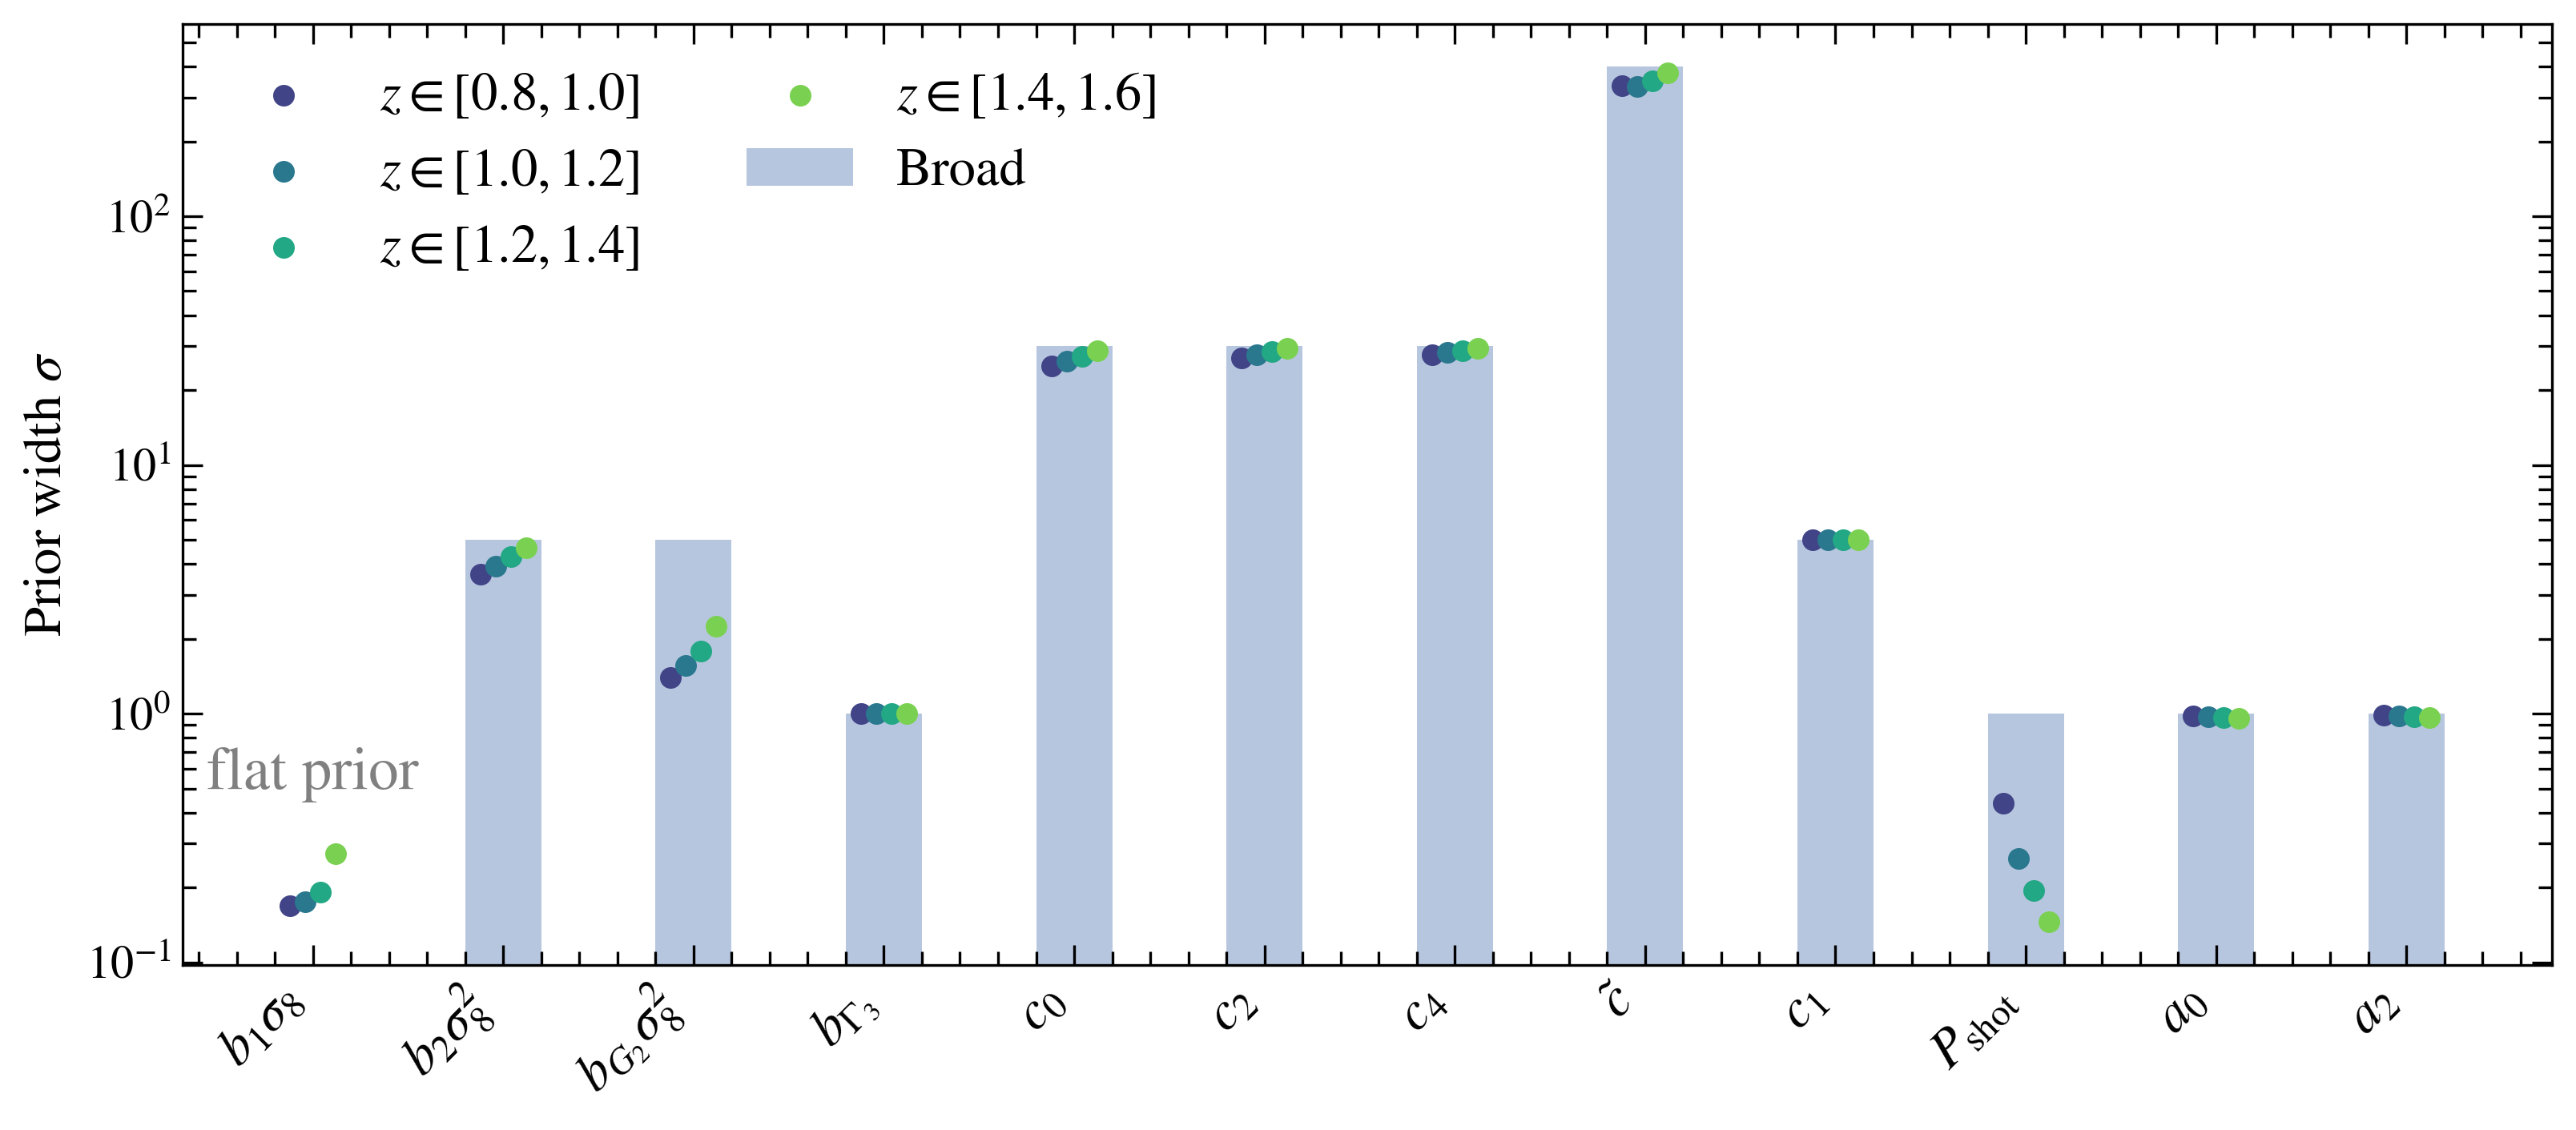

In [4]:
bp_dict = broad_priors().sigma_dict()
params_to_show = list(NUISANCE_NAMES)
plabels = {
    "b1_sigma8": r"$b_1\sigma_8$",
    "b2_sigma8sq": r"$b_2\sigma_8^2$", "bG2_sigma8sq": r"$b_{G_2}\sigma_8^2$",
    "bGamma3": r"$b_{\Gamma_3}$", "c0": r"$c_0$", "c2": r"$c_2$", "c4": r"$c_4$",
    "c_tilde": r"$\tilde{c}$", "c1": r"$c_1$",
    "Pshot": r"$P_{\rm shot}$", "a0": r"$a_0$", "a2": r"$a_2$",
}

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(params_to_show))

# Broad priors as bars (skip b1_sigma8 which has flat prior)
for i, p in enumerate(params_to_show):
    bv = bp_dict[p]
    if bv is not None:
        ax.bar(i, bv, 0.4, color="#4C72B0", alpha=0.4,
               label="Broad" if i == 1 else None)

# Calibrated priors per z-bin
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(sorted_zbins)))
for iz, zb in enumerate(sorted_zbins):
    cal = overlap[zb].calibrated_priors
    cal_vals = [cal.params.get(p, np.nan) for p in params_to_show]
    offset = (iz - len(sorted_zbins) / 2 + 0.5) * 0.08
    ax.scatter(x + offset, cal_vals, color=colors[iz], s=30, zorder=5,
               label=f"$z \\in [{zb[0]:.1f},{zb[1]:.1f}]$")

ax.set_xticks(x)
ax.set_xticklabels([plabels.get(p, p) for p in params_to_show],
                    rotation=45, ha="right", fontsize=16)
ax.set_ylabel(r"Prior width $\sigma$")
ax.set_yscale("log")
ax.legend(frameon=False, fontsize=16, ncol=2)

# Annotate b1_sigma8 as flat prior
b1_idx = params_to_show.index("b1_sigma8")
ax.annotate("flat prior", xy=(b1_idx, 0.5), fontsize=18, ha="center",
            color="gray", style="normal")

fig.tight_layout()
fig.savefig("paper/figs/calibrated_vs_broad.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure 2 --- Full-area DESI constraints (money figure)

Bar chart of marginalized sigma(fsigma8), sigma(Mnu), sigma(Omegam)
under three scenarios. SBP benchmark lines from Zhang+ 2025 (PS-level)
and Chudaykin+ 2026 (field-level). No field-level line for Mnu because
SBPs worsen the LCDM bound (Chudaykin+ 2026, Table IV).

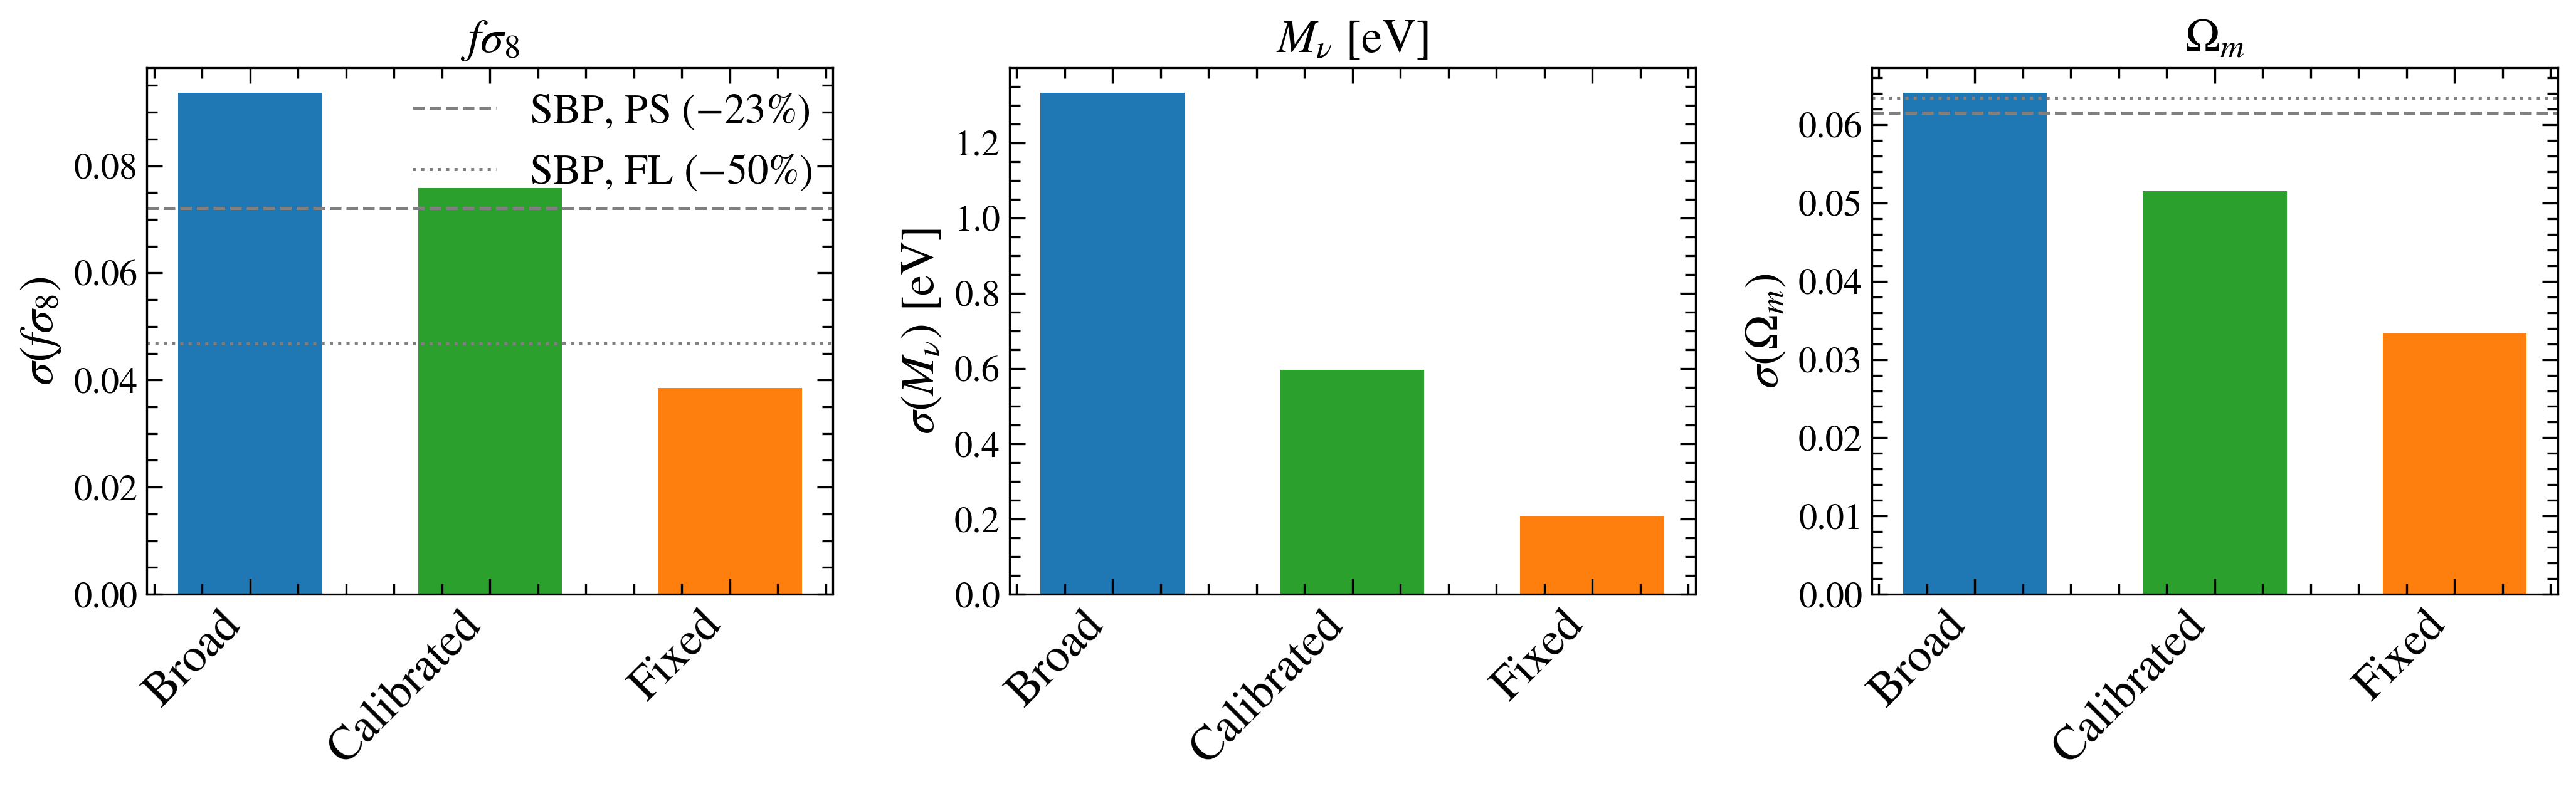


Headline numbers:
  Broad            $f\sigma_8$ : sigma = 9.3658e-02  (+0.0%)
  Broad            $M_\nu$ [eV]: sigma = 1.3330e+00  (+0.0%)
  Broad            $\Omega_m$  : sigma = 6.4101e-02  (+0.0%)
  Calibrated       $f\sigma_8$ : sigma = 7.5863e-02  (+19.0%)
  Calibrated       $M_\nu$ [eV]: sigma = 5.9642e-01  (+55.3%)
  Calibrated       $\Omega_m$  : sigma = 5.1529e-02  (+19.6%)
  Fixed            $f\sigma_8$ : sigma = 3.8470e-02  (+58.9%)
  Fixed            $M_\nu$ [eV]: sigma = 2.0867e-01  (+84.3%)
  Fixed            $\Omega_m$  : sigma = 3.3425e-02  (+47.9%)


In [5]:
param_titles = [r"$f\sigma_8$", r"$M_\nu$ [eV]", r"$\Omega_m$"]
param_ylabels = [r"$\sigma(f\sigma_8)$", r"$\sigma(M_\nu)$ [eV]", r"$\sigma(\Omega_m)$"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ip, (cp, title, ylabel) in enumerate(zip(cosmo_params, param_titles, param_ylabels)):
    ax = axes[ip]
    x = np.arange(len(scenario_names))
    vals = [scenarios[sn].sigmas_combined[cp] for sn in scenario_names]
    colors = [COLORS[sn] for sn in scenario_names]

    ax.bar(x, vals, color=colors, width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([LABELS[sn] for sn in scenario_names], rotation=45, ha="right", fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.set_title(title, fontsize=18)

    sigma_broad = scenarios["broad"].sigmas_combined[cp]

    if cp == "fsigma8":
        hod_imp = HOD_BENCHMARK["sigma8_improvement"]
        ax.axhline(sigma_broad * (1 - hod_imp), ls="--", color="gray",
                   lw=1.2, label=fr"SBP, PS ($-{hod_imp*100:.0f}$%)")
        fl_imp = FIELD_LEVEL_BENCHMARK["sigma8_improvement"]
        ax.axhline(sigma_broad * (1 - fl_imp), ls=":", color="gray",
                   lw=1.2, label=fr"SBP, FL ($-{fl_imp*100:.0f}$%)")
        ax.legend(frameon=False, loc="upper right", fontsize=16, bbox_to_anchor=(1.025,1.025))

    if cp == "Omegam":
        hod_imp = HOD_BENCHMARK["Omegam_improvement"]
        ax.axhline(sigma_broad * (1 - hod_imp), ls="--", color="gray", lw=1.2)
        fl_imp = FIELD_LEVEL_BENCHMARK["Omegam_improvement"]
        ax.axhline(sigma_broad * (1 - fl_imp), ls=":", color="gray", lw=1.2)

fig.tight_layout()
fig.savefig("paper/figs/full_area_constraints.png", dpi=200, bbox_inches="tight")
plt.show()

# Print headline numbers
print("\nHeadline numbers:")
sb = {cp: scenarios["broad"].sigmas_combined[cp] for cp in cosmo_params}
for sn in scenario_names:
    for cp, label in zip(cosmo_params, param_titles):
        s = scenarios[sn].sigmas_combined[cp]
        imp = (sb[cp] - s) / sb[cp] * 100
        print(f"  {LABELS[sn]:16s} {label:12s}: sigma = {s:.4e}  ({imp:+.1f}%)")

## Figure 3 --- Calibration efficiency per z-bin

Efficiency = (sigma_broad - sigma_xcal) / (sigma_broad - sigma_fixed).
0 = cross-cal adds nothing; 1 = achieves the fixed-nuisance limit.

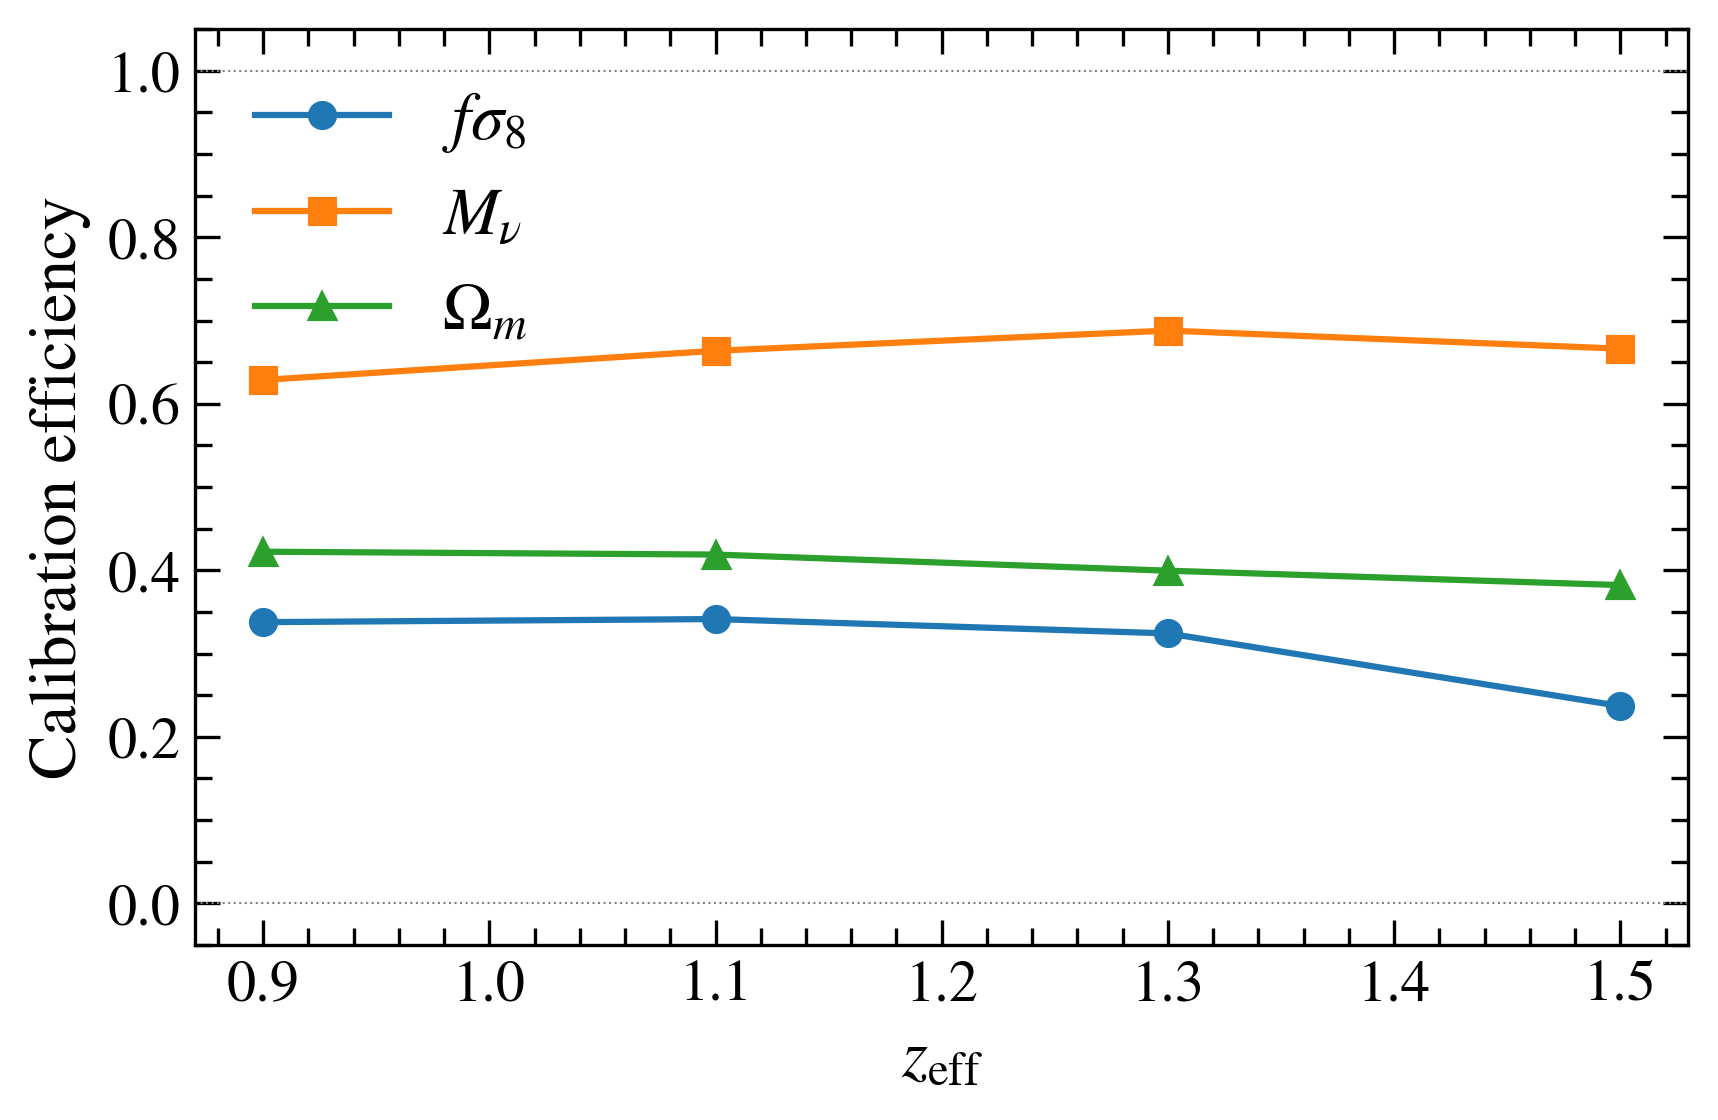

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))

markers = {"fsigma8": "o", "Mnu": "s", "Omegam": "^"}
clabels = {"fsigma8": r"$f\sigma_8$", "Mnu": r"$M_\nu$", "Omegam": r"$\Omega_m$"}
z_mids = [0.5 * (zb[0] + zb[1]) for zb in z_bins]

for cp in cosmo_params:
    effs = []
    for zb in z_bins:
        sb = scenarios["broad"].sigmas_per_z[zb][cp]
        so = scenarios["oracle"].sigmas_per_z[zb][cp]
        sx = scenarios["cross-cal"].sigmas_per_z[zb][cp]
        eff = compute_calibration_efficiency(sx, sb, so)
        effs.append(eff if eff is not None else 0.0)
    ax.plot(z_mids, effs, marker=markers[cp], label=clabels[cp], lw=1.5)

ax.set_xlabel(r"$z_{\rm eff}$")
ax.set_ylabel("Calibration efficiency")
ax.set_ylim(-0.05, 1.05)
ax.axhline(1.0, ls=":", color="gray", lw=0.5)
ax.axhline(0.0, ls=":", color="gray", lw=0.5)
ax.legend(frameon=False, fontsize=16)
fig.tight_layout()
fig.savefig("paper/figs/calibration_efficiency.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure 4 --- Sensitivity to r_sigma_v (two curves)

Two curves disentangle the r_sigma_v channels:
- **Asymmetric kmax** (green): kmax_PFS = kmax_DESI / r_sigma_v (default)
- **Symmetric kmax** (red): kmax_PFS = kmax_DESI = 0.20 (fixed)

The gap between the red curve and the broad baseline = gain from
multi-tracer stochastic/bias separation (independent of r_sigma_v).
The gap between green and red = additional gain from asymmetric kmax.

**This cell re-runs the pipeline for each r_sigma_v value (~30s each, ~5 min total).**

In [ ]:
r_values = [0.5, 0.6, 0.75, 0.9, 1.0]
sigma_asym = {}
sigma_sym = {}
broad_baseline = None

for r in r_values:
    # Asymmetric kmax (default)
    cfg_r = ForecastConfig(r_sigma_v=r, output_dir="results/_sweep_rsv")
    res_r = run_pipeline(cfg_r, verbose=False)
    sigma_asym[r] = res_r.scenario_results["cross-cal"].sigmas_combined["fsigma8"]
    if broad_baseline is None:
        broad_baseline = res_r.scenario_results["broad"].sigmas_combined["fsigma8"]

    # Symmetric kmax (fixed kmax_PFS = kmax_DESI)
    cfg_s = ForecastConfig(r_sigma_v=r, output_dir="results/_sweep_rsv",
                           kmax_pfs_overlap=0.20, kmax_cross_overlap=0.20)
    res_s = run_pipeline(cfg_s, verbose=False)
    sigma_sym[r] = res_s.scenario_results["cross-cal"].sigmas_combined["fsigma8"]

    imp_a = (broad_baseline - sigma_asym[r]) / broad_baseline * 100
    imp_s = (broad_baseline - sigma_sym[r]) / broad_baseline * 100
    print(f"  r_sv={r:.2f}: asym={sigma_asym[r]:.4e} ({imp_a:+.1f}%)  "
          f"sym={sigma_sym[r]:.4e} ({imp_s:+.1f}%)")

  r_sv=0.50: asym=7.2099e-02 (+23.0%)  sym=7.7355e-02 (+17.4%)


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

r_arr = sorted(sigma_asym.keys())
h1, = ax.plot(r_arr, [sigma_asym[r] for r in r_arr], "o-", color="C1",
              lw=2, ms=7, label=r"Asymmetric $k_{\max}$")
h2, = ax.plot(r_arr, [sigma_sym[r] for r in r_arr], "s--", color="C2",
              lw=2, ms=7, label=r"Symmetric $k_{\max}$")

h3 = ax.axhline(broad_baseline, ls=":", color="C0", lw=1, label="Broad baseline")
c = ['silver', 'gray']
h4 = ax.axhline(broad_baseline * 0.9, ls=':', color=c[0], lw=0.8, label=r"$-10$%")
h5 = ax.axhline(broad_baseline * 0.8, ls=':', color=c[1], lw=0.8, label=r"$-20$%")

ax.set_xlabel(r"$r_{\sigma_v} = \sigma_{v,\mathrm{PFS}} / \sigma_{v,\mathrm{DESI}}$")
ax.set_ylabel(r"$\sigma(f\sigma_8)$ combined")

leg1 = ax.legend(
    [h1, h2],
    [r"Asymmetric $k_{\max}$", r"Symmetric $k_{\max}$"],
    frameon=False,
    loc="upper left",
    fontsize=16,
    bbox_to_anchor=(0., 1.00),
)

ax.add_artist(leg1)

leg2 = ax.legend(
    [h3, h4, h5],
    ["Broad baseline", r"$-10$%", r"$-20$%"],
    frameon=False,
    loc="upper right",
    fontsize=16,
    bbox_to_anchor=(1.00, 1.00),
)

fig.tight_layout()
fig.savefig("paper/figs/sensitivity_rsigmav.png", dpi=200, bbox_inches="tight")
plt.show()

## Summary table

In [ ]:
print(f"{'Scenario':<18s} {'kmax':>5s}  {'sigma(fs8)':>10s}  {'D%':>6s}  "
      f"{'sigma(Mnu)':>10s}  {'D%':>6s}  {'sigma(Om)':>10s}  {'D%':>6s}")
print("-" * 85)

sb = {cp: scenarios["broad"].sigmas_combined[cp] for cp in cosmo_params}

for sn in scenario_names:
    sc = [s for s in SCENARIOS if s.name == sn][0]
    row = f"{LABELS[sn]:<18s} {sc.kmax:5.2f}"
    for cp in cosmo_params:
        s = scenarios[sn].sigmas_combined[cp]
        imp = (sb[cp] - s) / sb[cp] * 100
        row += f"  {s:10.4e}  {imp:+5.1f}%"
    print(row)

print()
print(f"kmax_DESI = {cfg.kmax_desi_overlap:.3f}, "
      f"kmax_PFS = {cfg.compute_kmax_pfs():.3f} h/Mpc  "
      f"(r_sv = {cfg.r_sigma_v})")
print(f"f_shared = {cfg.f_shared_elg}")
print(f"Overlap: {cfg.overlap_area_deg2:.0f} deg^2, "
      f"Full DESI: {cfg.desi_area_deg2:.0f} deg^2")
print(f"z-bins: {z_bins}")

## Appendix Figure A1 --- Derivative validation (autodiff vs finite difference)

Left: normalized derivatives |dP_0/dtheta_i| / P_0 for all 15 parameters.
Right: fractional autodiff-vs-finite-difference agreement for all 15 parameters.
Finite differences use adaptive step selection via `numdifftools` (Richardson extrapolation).

In [ ]:
import jax.numpy as jnp
from ps_1loop_jax import PowerSpectrum1Loop
from pfsfog.cosmo import FiducialCosmology, make_plin_func, make_growth_rate_func
from pfsfog.eft_params import desi_elg_fiducials, COSMO_NAMES
from pfsfog.ps1loop_adapter import fisher_to_ps1loop_auto
from pfsfog.derivatives import (
    dPell_dtheta_autodiff, dPell_dtheta_stencil,
    dPell_d_fsigma8, dPell_d_cosmo_stencil, dPell_d_cosmo_autodiff,
    _make_mutable,
)

ps = PowerSpectrum1Loop(do_irres=False)
cosmo_d = FiducialCosmology(backend="cosmopower")
z_eff = 0.9
s8 = cosmo_d.sigma8(z_eff); f_z = float(cosmo_d.f(z_eff)); h_d = cosmo_d.params["h"]
pk_data = cosmo_d.pk_data(z_eff)
b1_d, nbar_d = 1.3, 4e-4
fid = desi_elg_fiducials(b1_d, s8)
params_d = fisher_to_ps1loop_auto(fid, s8, f_z, h_d, nbar_d)
k_deriv = jnp.arange(0.01, 0.26, 0.005)
k_np = np.asarray(k_deriv)
P0_fid = np.asarray(ps.get_pk_ell(k_deriv, 0, pk_data, params_d))

# --- Cosmological derivatives: autodiff + finite-diff ---
pkdata_fn = make_plin_func("cosmopower")
f_fn_d = make_growth_rate_func()
cosmo_dict = dict(cosmo_d.params)

# fσ₈: autodiff (via chain rule through f) + finite-diff for validation
cosmo_derivs_d = {
    "fsigma8": np.asarray(dPell_d_fsigma8(ps, k_deriv, pk_data, params_d, s8, 0)),
}
# Finite-diff fσ₈ for right panel comparison
fid_f = params_d["f"]
h_step_f = 0.005
def _pk_of_fs8(delta):
    p = _make_mutable(params_d)
    p["f"] = fid_f + delta * s8
    return np.asarray(ps.get_pk_ell(k_deriv, 0, pk_data, p))
fsigma8_fd = (
    -_pk_of_fs8(2*h_step_f) + 8*_pk_of_fs8(h_step_f)
    - 8*_pk_of_fs8(-h_step_f) + _pk_of_fs8(-2*h_step_f)
) / (12 * h_step_f)

cosmo_ad = {"fsigma8": cosmo_derivs_d["fsigma8"]}
cosmo_fd_dict = {"fsigma8": fsigma8_fd}

# Mν, Ωm: autodiff through cosmopower-jax + finite-diff
for cp in ("Omegam", "Mnu"):
    cosmo_ad[cp] = np.asarray(dPell_d_cosmo_autodiff(
        ps, k_deriv, pkdata_fn, f_fn_d, cosmo_dict, params_d, cp, z_eff, s8, 0))
    cosmo_fd_dict[cp] = np.asarray(dPell_d_cosmo_stencil(
        ps, k_deriv, cosmo_d, params_d, cp, z_eff, s8, 0))
    cosmo_derivs_d[cp] = cosmo_ad[cp]

# --- Nuisance: autodiff + finite-diff ---
nuis_ad, nuis_fd = {}, {}
for pn in NUISANCE_NAMES:
    nuis_ad[pn] = np.asarray(dPell_dtheta_autodiff(ps, k_deriv, pk_data, params_d, pn, s8, 0))
    nuis_fd[pn] = np.asarray(dPell_dtheta_stencil(ps, k_deriv, pk_data, params_d, pn, s8, 0))

# Plot groups
GROUPS = {
    "Cosmo": (["fsigma8","Mnu","Omegam"],
              [r"$f\sigma_8$",r"$M_\nu$",r"$\Omega_m$"],
              ["#E24A33","#348ABD","#988ED5"]),
    "Bias": (["b1_sigma8","b2_sigma8sq","bG2_sigma8sq","bGamma3"],
             [r"$b_1\sigma_8$",r"$b_2\sigma_8^2$",r"$b_{G_2}\sigma_8^2$",r"$b_{\Gamma_3}$"],
             ["#2ca02c","#98df8a","#006400","#90EE90"]),
    "Ctr": (["c0","c2","c4","c_tilde","c1"],
            [r"$c_0$",r"$c_2$",r"$c_4$",r"$\tilde{c}$",r"$c_1$"],
            ["#ff7f0e","#ffbb78","#d62728","#ff9896","#bcbd22"]),
    "Stoch": (["Pshot","a0","a2"],
              [r"$P_{\rm shot}$",r"$a_0$",r"$a_2$"],
              ["#17becf","#9edae5","#7f7f7f"]),
}

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# -----------------------------
# LEFT: derivative landscape
# -----------------------------
cosmo_handles1, cosmo_labels1 = [], []
eft_handles1, eft_labels1 = [], []

for gn, (pnames, labels, colors) in GROUPS.items():
    for pn, lab, col in zip(pnames, labels, colors):
        d = cosmo_derivs_d.get(pn, nuis_ad.get(pn))
        if d is None:
            continue
        nd = np.abs(d) / np.abs(P0_fid)
        if np.max(nd) < 1e-10:
            continue

        h, = ax1.semilogy(k_np, nd, lw=1.3, color=col, label=lab)

        if gn == "Cosmo":
            cosmo_handles1.append(h)
            cosmo_labels1.append(lab)
        else:
            eft_handles1.append(h)
            eft_labels1.append(lab)

ax1.set_xlabel(r"$k$ [$h\,\mathrm{Mpc}^{-1}$]", fontsize=18)
ax1.set_ylabel(r"$|\partial P_0 / \partial \theta_i| / P_0$", fontsize=18)
ax1.set_ylim(5e-12, 5e4)

leg1_cosmo = ax1.legend(
    cosmo_handles1,
    cosmo_labels1,
    frameon=False,
    fontsize=16,
    ncol=1,
    loc="upper left",
    bbox_to_anchor=(0.00, 1.025),
)
ax1.add_artist(leg1_cosmo)

leg1_eft = ax1.legend(
    eft_handles1,
    eft_labels1,
    frameon=False,
    fontsize=16,
    ncol=3,
    loc="lower right",
    bbox_to_anchor=(1.00, -0.025),
)

# -----------------------------
# RIGHT: autodiff vs finite diff
# -----------------------------
cosmo_handles2, cosmo_labels2 = [], []
eft_handles2, eft_labels2 = [], []

# Cosmology
for cp, lab, col in [
    ("fsigma8", r"$f\sigma_8$", "#E24A33"),
    ("Mnu", r"$M_\nu$", "#348ABD"),
    ("Omegam", r"$\Omega_m$", "#988ED5"),
]:
    ad = cosmo_ad[cp]
    fd = cosmo_fd_dict[cp]
    scale = np.maximum(np.abs(ad), np.abs(fd))
    mask = scale > 1e-10 * np.max(scale)

    frac = np.full_like(ad, np.nan)
    frac[mask] = np.abs(ad[mask] - fd[mask]) / scale[mask]

    if np.all(np.isnan(frac)) or np.nanmax(frac) < 1e-15:
        continue

    h, = ax2.semilogy(k_np, frac, lw=1.5, color=col, label=lab, alpha=0.9)
    cosmo_handles2.append(h)
    cosmo_labels2.append(lab)

# EFT / nuisance
for gn, (pnames, labels, colors) in GROUPS.items():
    if gn == "Cosmo":
        continue
    for pn, lab, col in zip(pnames, labels, colors):
        ad, fd = nuis_ad.get(pn), nuis_fd.get(pn)
        if ad is None:
            continue

        scale = np.maximum(np.abs(ad), np.abs(fd))
        mask = scale > 1e-10 * np.max(scale)

        frac = np.full_like(ad, np.nan)
        frac[mask] = np.abs(ad[mask] - fd[mask]) / scale[mask]

        if np.all(np.isnan(frac)) or np.nanmax(frac) < 1e-15:
            continue

        h, = ax2.semilogy(k_np, frac, lw=1.0, color=col, label=lab, alpha=0.8)
        eft_handles2.append(h)
        eft_labels2.append(lab)

ax2.set_xlabel(r"$k$ [$h\,\mathrm{Mpc}^{-1}$]", fontsize=18)
ax2.set_ylabel(r"$|\mathrm{autodiff} - \mathrm{numdiff}| / |\max|$", fontsize=18)
ax2.set_ylim(1e-20, 1e-7)

leg2_cosmo = ax2.legend(
    cosmo_handles2,
    cosmo_labels2,
    frameon=False,
    fontsize=16,
    ncol=1,
    loc="upper right",
    bbox_to_anchor=(1.00, 1.00),
)
ax2.add_artist(leg2_cosmo)

leg2_eft = ax2.legend(
    eft_handles2,
    eft_labels2,
    frameon=False,
    fontsize=16,
    ncol=3,
    loc="lower left",
    bbox_to_anchor=(0.00, -0.025),
)

fig.tight_layout()
fig.savefig("paper/figs/deriv_autodiff_vs_numdiff.png", dpi=200, bbox_inches="tight")
plt.show()

## Appendix Figure A2 --- McDonald-Seljak convergence

Single-tracer vs multi-tracer sigma^2(Pm)/Pm^2 as a function of nbar.
The multi-tracer curve converges to the cosmic-variance-free floor
2/N_modes; the single-tracer plateaus above it due to the b-f degeneracy.

In [ ]:
from numpy.polynomial.legendre import leggauss

bA, bB, f_ms, Pm = 1.0, 2.0, 0.8, 1e3  # Pm ~ P(k=0.1) in (Mpc/h)^3
k_ms, dk_ms, V_ms = 0.1, 0.01, 1e9
Nmodes_ms = k_ms**2 * dk_ms * V_ms / (2 * np.pi**2)
mu_gl, w_gl = leggauss(100)

def _sigma2_st(nbar):
    F = np.zeros((2, 2))
    for mi, wi in zip(mu_gl, w_gl):
        sA = bA + f_ms * mi**2
        PAA = sA**2 * Pm + 1.0 / nbar
        D = np.array([sA**2, 2.0 * sA * Pm])
        F += wi * np.outer(D, D) / (2.0 * PAA**2)
    F *= Nmodes_ms / 2.0
    return 1.0 / (F[0, 0] - F[0, 1]**2 / F[1, 1])

def _sigma2_mt(nbar):
    F = np.zeros((3, 3))
    for mi, wi in zip(mu_gl, w_gl):
        sA = bA + f_ms * mi**2
        sB = bB + f_ms * mi**2
        PAA = sA**2 * Pm + 1.0 / nbar
        PBB = sB**2 * Pm + 1.0 / nbar
        PAB = sA * sB * Pm
        C3 = np.array([
            [2*PAA**2,     2*PAB**2,        2*PAA*PAB],
            [2*PAB**2,     2*PBB**2,        2*PBB*PAB],
            [2*PAA*PAB,    2*PBB*PAB,       PAA*PBB + PAB**2]])
        D = np.array([
            [sA**2,   2*sA*Pm, 0.0],
            [sB**2,   0.0,     2*sB*Pm],
            [sA*sB,   sB*Pm,   sA*Pm]])
        F += wi * D.T @ np.linalg.inv(C3) @ D
    F *= Nmodes_ms / 2.0
    Fb = F[1:, 1:]
    Fc = F[0, 1:]
    return 1.0 / (F[0, 0] - Fc @ np.linalg.solve(Fb, Fc))

def _sigma2_mt_fixed_bB(nbar):
    """Multi-tracer with bB fixed, marginalise over bA only."""
    F = np.zeros((2, 2))
    for mi, wi in zip(mu_gl, w_gl):
        sA = bA + f_ms * mi**2
        sB = bB + f_ms * mi**2
        PAA = sA**2 * Pm + 1.0 / nbar
        PBB = sB**2 * Pm + 1.0 / nbar
        PAB = sA * sB * Pm
        C3 = np.array([
            [2*PAA**2,     2*PAB**2,        2*PAA*PAB],
            [2*PAB**2,     2*PBB**2,        2*PBB*PAB],
            [2*PAA*PAB,    2*PBB*PAB,       PAA*PBB + PAB**2]])
        D = np.array([
            [sA**2,   2*sA*Pm],
            [sB**2,   0.0],
            [sA*sB,   sB*Pm]])
        F += wi * D.T @ np.linalg.inv(C3) @ D
    F *= Nmodes_ms / 2.0
    return 1.0 / (F[0, 0] - F[0, 1]**2 / F[1, 1])

nbars_ms = np.logspace(-4, 3, 200)
s2_st = np.array([_sigma2_st(n) for n in nbars_ms])
s2_mt = np.array([_sigma2_mt(n) for n in nbars_ms])
s2_mt_fixB = np.array([_sigma2_mt_fixed_bB(n) for n in nbars_ms])
cv_floor = 2.0 * Pm**2 / Nmodes_ms

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.loglog(nbars_ms, s2_st / Pm**2, ls="-", color="#4C72B0", lw=2,
          label=r"Single-tracer ($b_A$ marginalised)")
ax.loglog(nbars_ms, s2_mt / Pm**2, ls="-", color="#DD8452", lw=2,
          label=r"Multi-tracer ($b_A, b_B$ marginalised)")
#ax.loglog(nbars_ms, s2_mt_fixB / Pm**2, ls="-.", color="#DD8452", lw=1.5, alpha=0.7,
          #label=r"Multi-tracer ($b_B$ fixed)")
ax.axhline(cv_floor / Pm**2, ls="--", color="k", lw=1.2,
           label=r"CV-free floor $2/N_{\rm modes}$")

# Typical survey nbar range
ax.axvspan(5e-4, 1e-3, color="gray", alpha=0.10, zorder=0)
ax.text(7.8e-4, 5e-4, r"PFS and DESI $\bar{n}$", color="gray",
        fontsize=16, ha="center", rotation=90)

ax.set_xlabel(r"$\bar{n}$ [$(h^{-1}\,\mathrm{Mpc})^{-3}$]")
ax.set_ylabel(r"$\sigma^2(P_m)\,/\,P_m^2$")
ax.set_xlim(1e-4, 1e2)
ax.legend(frameon=False, fontsize=16, loc="upper right")
fig.tight_layout()
fig.savefig("paper/figs/ms09_convergence.png", dpi=200, bbox_inches="tight")
plt.show()

## Appendix Figure A3 --- Fisher information density

Conditional vs marginalized Fisher information density dF_ii/dk for
fσ₈, Mν, Ωm. The gap between the two curves shows how much
information is lost to nuisance marginalization at each k.

In [ ]:
from pfsfog.derivatives import dPell_dtheta_autodiff_all, dPell_d_cosmo_all
from pfsfog.covariance import single_tracer_cov
from pfsfog.fisher_full_area import full_area_fisher_per_zbin
from pfsfog.surveys import desi_elg as make_desi_elg
from pfsfog.eft_params import COSMO_PRIOR_SIGMA
from pfsfog.ps1loop_adapter import make_ps1loop_pkmu_func

desi_fi = make_desi_elg()
ells_fi = (0,2,4); kmax_fi = 0.20
k_fi = np.arange(cfg.kmin, kmax_fi + cfg.dk/2, cfg.dk)
zlo_fi, zhi_fi = 0.8, 1.0
z_fi = 0.9
s8_fi = cosmo_d.sigma8(z_fi); f_fi = float(cosmo_d.f(z_fi))
nbar_fi = desi_fi.nbar_eff(zlo_fi, zhi_fi)
b1_fi = desi_fi.b1_of_z(z_fi); V_fi = desi_fi.volume(zlo_fi, zhi_fi)
pk_fi = cosmo_d.pk_data(z_fi)
fid_fi = desi_elg_fiducials(b1_fi, s8_fi)
par_fi = fisher_to_ps1loop_auto(fid_fi, s8_fi, f_fi, cosmo_d.params["h"], nbar_fi)

derivs_fi = dPell_dtheta_autodiff_all(ps, jnp.array(k_fi), pk_fi, par_fi, NUISANCE_NAMES, s8_fi, ells_fi)
derivs_fi.update(dPell_d_cosmo_all(ps, jnp.array(k_fi), pk_fi, cosmo_d, par_fi, z_fi, s8_fi, ells_fi))
pkmu_fi = make_ps1loop_pkmu_func(ps, pk_fi, par_fi)
cov_fi = single_tracer_cov(pkmu_fi, k_fi, nbar_fi, V_fi, cfg.dk, ells_fi)

N_C = len(COSMO_NAMES); N_N = len(NUISANCE_NAMES); Np = N_C + N_N
Nk = len(k_fi); Nell = len(ells_fi)
D_fi = np.zeros((Nk, Nell, Np))
for ic, cn in enumerate(COSMO_NAMES):
    for il, ell in enumerate(ells_fi):
        if cn in derivs_fi and ell in derivs_fi[cn]:
            D_fi[:,il,ic] = np.asarray(derivs_fi[cn][ell])
for ip, nn in enumerate(NUISANCE_NAMES):
    for il, ell in enumerate(ells_fi):
        if nn in derivs_fi and ell in derivs_fi[nn]:
            D_fi[:,il,N_C+ip] = np.asarray(derivs_fi[nn][ell])

info_cond = {cn: np.zeros(Nk) for cn in COSMO_NAMES}
info_marg = {cn: np.zeros(Nk) for cn in COSMO_NAMES}

for ik in range(Nk):
    ci = np.linalg.inv(cov_fi[ik])
    Fk = D_fi[ik].T @ ci @ D_fi[ik]
    for ic, cn in enumerate(COSMO_NAMES):
        info_cond[cn][ik] = Fk[ic, ic]

bp_d = broad_priors().prior_fisher_diag()
pf = np.zeros(Np); pf[N_C:] = bp_d
for i, cn in enumerate(COSMO_NAMES):
    pf[i] = 1.0 / COSMO_PRIOR_SIGMA[cn]**2
F_cum = np.diag(pf).copy()
prev = {cn: pf[i] for i, cn in enumerate(COSMO_NAMES)}
for ik in range(Nk):
    ci = np.linalg.inv(cov_fi[ik])
    F_cum += D_fi[ik].T @ ci @ D_fi[ik] * cfg.dk
    try:
        C_cum = np.linalg.inv(F_cum)
        for ic, cn in enumerate(COSMO_NAMES):
            mf = 1.0 / C_cum[ic,ic]
            info_marg[cn][ik] = (mf - prev[cn]) / cfg.dk
            prev[cn] = mf
    except: pass

In [ ]:
clabels_fi = {"fsigma8": r"$f\sigma_8$", "Mnu": r"$M_\nu$", "Omegam": r"$\Omega_m$"}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ic, (cn, ax) in enumerate(zip(COSMO_NAMES, axes)):
    ax.semilogy(k_fi, info_cond[cn], "-", color="#4C72B0", lw=2, label="Conditional")
    ax.semilogy(k_fi, np.maximum(info_marg[cn], 1e-10), "-", color="#DD8452", lw=2, label="Marginalized")
    ax.set_xlabel(r"$k$ [$h\,\mathrm{Mpc}^{-1}$]"); ax.set_title(clabels_fi[cn],fontsize=18)
    if ic == 0: ax.set_ylabel(r"$\mathrm{d}F_{ii}/\mathrm{d}k$", fontsize=16); ax.legend(frameon=False, fontsize=18, loc='upper left', bbox_to_anchor=(0.00,1.03))
fig.tight_layout()
fig.savefig("paper/figs/fisher_info_density.png", dpi=200, bbox_inches="tight")
plt.show()

## Appendix Figure A4 --- Covariance validation (GL vs Wigner 3j)

Validates the 20-point Gauss-Legendre covariance against the analytic
Wigner 3j decomposition (Rubira & Conteddu 2025, Eq. 2.20). Shaded
bands span the range of fractional differences across all covariance
elements (6 spectrum-pair types × 6 multipole combinations). Each step
in ℓ_max gains ~3 orders of magnitude, confirming that the one-loop EFT
model has non-negligible ℓ>4 content and that GL quadrature captures it
automatically.

In [ ]:
from sympy.physics.wigner import wigner_3j as _wigner_3j
from numpy.polynomial.legendre import leggauss as _leggauss
from pfsfog.surveys import pfs_elg as make_pfs_elg, desi_elg as make_desi_elg
from pfsfog.cosmo import FiducialCosmology
from pfsfog.eft_params import tracer_fiducials
from pfsfog.ps1loop_adapter import (
    fisher_to_ps1loop_auto, fisher_to_ps1loop_cross,
    make_ps1loop_pkmu_func, make_ps1loop_pkmu_cross_func,
)
from ps_1loop_jax import PowerSpectrum1Loop

_LS_COV = {
    4: "-",
    6: "--",
    8: "-.",
}
_COL_COV = {
    4: "#4C72B0",
    6: "#7B6EB0",
    8: "#A86CA8",
}

def _legpoly(ell, mu):
    if ell == 0: return np.ones_like(mu)
    if ell == 2: return 0.5 * (3 * mu**2 - 1)
    if ell == 4: return (1/8) * (35 * mu**4 - 30 * mu**2 + 3)
    if ell == 6: return (1/16) * (231 * mu**6 - 315 * mu**4 + 105 * mu**2 - 5)
    if ell == 8: return (1/128) * (6435 * mu**8 - 12012 * mu**6 + 6930 * mu**4 - 1260 * mu**2 + 35)

_w3j_cache = {}
def _w3j_sq(l1, l2, l3):
    key = (l1, l2, l3)
    if key not in _w3j_cache:
        v = float(_wigner_3j(l1, l2, l3, 0, 0, 0))
        _w3j_cache[key] = v * v
    return _w3j_cache[key]

def _decompose(Pkmu, mu, w, ells):
    return {ell: (2*ell+1)/2 * np.sum(_legpoly(ell, mu)[None,:] * Pkmu * w[None,:], axis=1) for ell in ells}

def _cov_w3j(PXW, PYZ, PXZ, PYW, el, elp, Nm, dells):
    res = np.zeros(len(Nm))
    for l1 in dells:
        for l2 in dells:
            for l3 in range(abs(l1-l2), l1+l2+1):
                w1 = _w3j_sq(l1, l2, l3)
                if w1 == 0: continue
                w2 = _w3j_sq(el, elp, l3)
                if w2 == 0: continue
                res += (2*l3+1)*w1*w2*((-1)**elp * PXW[l1]*PYZ[l2] + PXZ[l1]*PYW[l2])
    return (2*el+1)*(2*elp+1)/Nm * res

def _cov_gl(XW, YZ, XZ, YW, el, elp, Nm, mu, w):
    Le, Lep = _legpoly(el, mu), _legpoly(elp, mu)
    integ = Le[None,:]*Lep[None,:]*(XW*YZ + XZ*YW)*w[None,:]
    return (2*el+1)*(2*elp+1)/(2*Nm) * np.sum(integ, axis=1)

# Self-contained setup (no dependency on earlier cells except cfg and np)
cosmo_cv = FiducialCosmology(backend="cosmopower")
ps_cv = PowerSpectrum1Loop(do_irres=False)

pfs_cv = make_pfs_elg(); desi_cv = make_desi_elg()
z_cv = 0.9; s8_cv = cosmo_cv.sigma8(z_cv); f_cv = float(cosmo_cv.f(z_cv)); h_cv = cosmo_cv.params["h"]
pk_cv = cosmo_cv.pk_data(z_cv)
nb_A = pfs_cv.nbar_eff(0.8, 1.0); nb_B = desi_cv.nbar_eff(0.8, 1.0)
b1_A_cv = pfs_cv.b1_of_z(z_cv); b1_B_cv = desi_cv.b1_of_z(z_cv)
fid_Acv = tracer_fiducials("PFS-ELG", b1_A_cv, s8_cv, b1_ref=b1_B_cv, r_sigma_v=cfg.r_sigma_v)
fid_Bcv = tracer_fiducials("DESI-ELG", b1_B_cv, s8_cv)
par_Acv = fisher_to_ps1loop_auto(fid_Acv, s8_cv, f_cv, h_cv, nb_A)
par_Bcv = fisher_to_ps1loop_auto(fid_Bcv, s8_cv, f_cv, h_cv, nb_B)
xpar = fisher_to_ps1loop_cross(fid_Acv, fid_Bcv, s8_cv, f_cv, h_cv, nb_A, nb_B)
pkmu_Acv = make_ps1loop_pkmu_func(ps_cv, pk_cv, par_Acv)
pkmu_Bcv = make_ps1loop_pkmu_func(ps_cv, pk_cv, par_Bcv)
pkmu_ABcv = make_ps1loop_pkmu_cross_func(ps_cv, pk_cv, xpar)

k_cv = np.arange(cfg.kmin, 0.25 + cfg.dk/2, cfg.dk)
mu_cv, w_cv = _leggauss(20)
V_cv = 5.88e8
Nm_cv = k_cv**2 * cfg.dk * V_cv / (2*np.pi**2)
PAA = np.asarray(pkmu_Acv(k_cv, mu_cv)) + 1/nb_A
PBB = np.asarray(pkmu_Bcv(k_cv, mu_cv)) + 1/nb_B
PAB = np.asarray(pkmu_ABcv(k_cv, mu_cv))

# Compute fractional differences for all elements at each ell_max
ell_pairs_cv = [(0,0),(0,2),(0,4),(2,2),(2,4),(4,4)]
spec_cv = [
    (PAA,PAA,PAA,PAA), (PAA,PBB,PAB,PAB), (PAA,PAB,PAB,PAA),
    (PBB,PBB,PBB,PBB), (PAB,PBB,PBB,PAB), (PAB,PAB,PAB,PAB),
]
results_cv = {}
for lmax in [4, 6, 8]:
    dells = tuple(range(0, lmax+1, 2))
    pAA = _decompose(PAA, mu_cv, w_cv, dells)
    pBB = _decompose(PBB, mu_cv, w_cv, dells)
    pAB = _decompose(PAB, mu_cv, w_cv, dells)
    pm = {id(PAA): pAA, id(PBB): pBB, id(PAB): pAB}
    fracs = []
    for (xw, yz, xz, yw) in spec_cv:
        for (el, elp) in ell_pairs_cv:
            cgl = _cov_gl(xw, yz, xz, yw, el, elp, Nm_cv, mu_cv, w_cv)
            cw3 = _cov_w3j(pm[id(xw)], pm[id(yz)], pm[id(xz)], pm[id(yw)], el, elp, Nm_cv, dells)
            with np.errstate(divide="ignore", invalid="ignore"):
                fr = np.abs(cgl - cw3) / np.abs(cgl)
            fr[np.abs(cgl) < 1e-30] = np.nan
            fracs.append(fr)
    results_cv[lmax] = np.array(fracs)

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
for lmax in [4, 6, 8]:
    fr = results_cv[lmax]
    lo = np.nanmin(fr, axis=0); hi = np.nanmax(fr, axis=0)
    med = np.nanmedian(fr, axis=0)
    ax.fill_between(k_cv, lo, hi, color=_COL_COV[lmax], alpha=0.28)
    ax.semilogy(
     k_cv,
     med,
     color=_COL_COV[lmax],
     ls=_LS_COV[lmax],
     lw=1.8,
     label=rf"$\ell_{{\max}}={lmax}$",
)
ax.set_xlabel(r"$k\;[h\,\mathrm{Mpc}^{-1}]$")
ax.set_ylabel(r"$|\mathrm{Cov}_{\mathrm{GL}} - \mathrm{Cov}_{\mathrm{W3}j}| / |\mathrm{Cov}_{\mathrm{GL}}|$")
ax.set_ylim(1e-18, 1)
ax.legend(loc="lower right", title=r"Wigner 3$j$ truncation",
          frameon=False, fancybox=False, edgecolor="0.8",bbox_to_anchor=(1.0,0.0))
fig.tight_layout()
fig.savefig("paper/figs/cov_gl_vs_wigner3j.png", dpi=200, bbox_inches="tight")
plt.show()

for lmax in [4, 6, 8]:
    print(f"  ell_max={lmax}: max={np.nanmax(results_cv[lmax]):.2e}, "
          f"median={np.nanmedian(results_cv[lmax]):.2e}")

## Fisher contour plot --- b1-f degeneracy visualization

2D Fisher ellipses (1σ and 2σ) for broad vs cross-cal priors.
Three panels show the key degeneracies: b₁σ₈–Mν (dominant),
b₁σ₈–fσ₈, and fσ₈–Mν (marginalized cosmological contour).
Uses the combined 4-z-bin single-ELG Fisher for visualization.

In [ ]:
from matplotlib.patches import Ellipse
from pfsfog.eft_params import desi_elg_fiducials
from pfsfog.ps1loop_adapter import fisher_to_ps1loop_auto, make_ps1loop_pkmu_func
from pfsfog.derivatives import dPell_dtheta_autodiff_all, dPell_d_cosmo_all
from pfsfog.covariance import single_tracer_cov
from pfsfog.fisher_full_area import full_area_fisher_per_zbin, combine_zbins
from pfsfog.surveys import desi_elg as make_desi_elg
from pfsfog.prior_export import calibrated_prior_fisher_diag
from pfsfog.cosmo import FiducialCosmology

cosmo_fc = FiducialCosmology(backend="cosmopower")
from ps_1loop_jax import PowerSpectrum1Loop
ps_fc = PowerSpectrum1Loop(do_irres=False)
ells_fc = (0, 2, 4); kmax_fc = 0.20
k_fc = np.arange(cfg.kmin, kmax_fc + cfg.dk / 2, cfg.dk)
desi_fc = make_desi_elg()

def build_fisher(scenario):
    fishers = []
    for zlo, zhi in z_bins:
        z_eff = 0.5 * (zlo + zhi)
        s8 = cosmo_fc.sigma8(z_eff); f_z = float(cosmo_fc.f(z_eff)); h = cosmo_fc.params["h"]
        nbar = desi_fc.nbar_eff(zlo, zhi)
        if nbar == 0: continue
        b1 = desi_fc.b1_of_z(z_eff); V = desi_fc.volume(zlo, zhi)
        pk_data = cosmo_fc.pk_data(z_eff)
        fid = desi_elg_fiducials(b1, s8)
        params = fisher_to_ps1loop_auto(fid, s8, f_z, h, nbar)
        derivs = dPell_dtheta_autodiff_all(ps_fc, jnp.array(k_fc), pk_data, params, NUISANCE_NAMES, s8, ells_fc)
        derivs.update(dPell_d_cosmo_all(ps_fc, jnp.array(k_fc), pk_data, cosmo_fc, params, z_eff, s8, ells_fc))
        pkmu = make_ps1loop_pkmu_func(ps_fc, pk_data, params)
        cov = single_tracer_cov(pkmu, k_fc, nbar, V, cfg.dk, ells_fc)
        if scenario == "broad":
            npd = broad_priors().prior_fisher_diag()
        else:
            ov = overlap.get((zlo, zhi))
            npd = calibrated_prior_fisher_diag(ov.calibrated_priors) if ov else broad_priors().prior_fisher_diag()
        fishers.append(full_area_fisher_per_zbin(derivs, cov, k_fc, cfg.dk, npd, (zlo, zhi), kmax_fc, ells_fc))
    return combine_zbins(fishers, z_bins)

fr_b = build_fisher("broad"); fr_c = build_fisher("cross-cal")
Cb = np.linalg.inv(fr_b.F); Cc = np.linalg.inv(fr_c.F)
pn = fr_b.param_names
i_f = pn.index("fsigma8"); i_m = pn.index("Mnu"); i_b = pn.index("b1_sigma8_z0.8_1.0")
xf = float(cosmo_fc.f(0.9)) * cosmo_fc.sigma8(0.9); xm = 0.06
xb = desi_fc.b1_of_z(0.9) * cosmo_fc.sigma8(0.9)

panels = [
    (i_b, i_m, r"$b_1\sigma_8", r"$M_\nu$ [eV]", xb, xm),
    (i_b, i_f, r"$b_1\sigma_8$", r"$f\sigma_8$", xb, xf),
    (i_f, i_m, r"$f\sigma_8$", r"$M_\nu$ [eV]", xf, xm),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (ix, iy, xl, yl, xc, yc) in zip(axes, panels):
    for C, col, lab in [(Cb, "#4C72B0", "Broad"), (Cc, "#55A868", "Calibrated")]:
        c2 = np.array([[C[ix, ix], C[ix, iy]], [C[iy, ix], C[iy, iy]]])
        vals, vecs = np.linalg.eigh(c2)
        vals = np.maximum(vals, 1e-30)
        ang = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
        for ns, al in [(1, 0.35), (2, 0.12)]:
            e = Ellipse(xy=(xc, yc), width=2*ns*np.sqrt(vals[0]),
                        height=2*ns*np.sqrt(vals[1]), angle=ang,
                        fill=True, facecolor=col, alpha=al,
                        edgecolor=col, linewidth=1.5)
            ax.add_patch(e)
        ax.plot([], [], color=col, lw=2, label=lab)
    ax.set_xlabel(xl, fontsize=18); ax.set_ylabel(yl, fontsize=18)
    ax.autoscale_view()
    x1, x2 = ax.get_xlim(); y1, y2 = ax.get_ylim()
    dx = (x2 - x1) * 0.15; dy = (y2 - y1) * 0.15
    ax.set_xlim(x1 - dx, x2 + dx); ax.set_ylim(y1 - dy, y2 + dy)
    ax.plot(xc, yc, "+", color="k", ms=8, mew=1.5)
axes[0].legend(frameon=False, fontsize=16, loc="upper left", bbox_to_anchor=(0.00,1.025))
fig.tight_layout()
fig.savefig("paper/figs/fisher_contours.png", dpi=200, bbox_inches="tight")
plt.show()